In [ ]:
Content
1. Inference Time Technique
2. Model Training
3. Training Techniques
4. Fine Tuneing with Closed Source LLM models
5. Fine Tuneing with Open Source LLM models
6. Hyper Parameters
7. Saving Training Logs
8. Structured Outputs from an LLM

In [ ]:
# Approaches to increase performance of a Gen AI solution.
1. Training Time Technique: Improving the performance of an LLM as part of the process to set the parameters of the model.
    a. Fine-Tuning a model
        - Take a pre-trained base model and train it with some proprietary data.
        - Transfer Learning: LLMs usually retain their base knowledge.
        - Fine Tuning can be done with Frontier/ Open Source Models
        - It's a high risk (cost of development and time) and high reward startegy, because the outputs are uncertain.
        - It requires large dataset with prompts and responses.
        - When to go with this: When you want your model to learn a new skill that generalizes, which other frontier model can not do.
                - You must have a lot of proprietry data for training.
                    
        a. Fine Tuning with Frontier Model
            - The labs have an API for fine-tuning
            - Used add nuance, tone, perhaps correct for special case.
        b. Fine Tuning with Open Source Model
            - Your own Proprietry Model
            - Train it with large dataset.

                
                
2. Inference Time Technique: Improving the performance of an LLM after training is over, as part of model inference.    
    a. Improving Prompt
        - Chain of Thought
    b. RAG
        - A way to add relevant context to the prompt to the LLM.
        - Improve the prompt with context from a Knowledge Base
        - Encoding: Convert text to numbers, so that can be saved in vector DB. and later a search query can be done on the context meaning of our question.
                - Similar vector, represents similar meaning. Consider it like two points closer in a N-Dimension space. 
        - Easy to update model. The model output are predictable and explainable.

# 1. Inference Time Technique

In [ ]:
# Inference Time Technique to get better answers
1. Multi-shot prompting
2. Tools/ Functions Calling
3. RAG/ Knowledge Base

# 2. Model Training

In [ ]:
- Model Training: It involves the parameters of a model based on input and output
- Generalization: The ability of a model to make good predictions on unseen data is called "Generalization" and LLMs are very good at this.
- Model Training requires million of dollar.
- We will use Transfer Learning: We take a pre-trained model as base, and use additional training data to fine-tune it.

In [ ]:
# Required Websites for Training

1. WandB:
    - For Logging Training results and interim training graphs
    - https://wandb.ai/srvaggarwal96-abes/amazon-product-price?nw=nwusersrvaggarwal96

2. Hugging Face:
    - To upload fine-tuned model and dataset.
    - https://huggingface.co/SouravAggarwal96/amazon-product-price-2026-01-09_09.59.38-lite/commits/main

### 2.1 Steps for Training

In [ ]:
Training: Tweaking the parameters of a model based on training data, in a way that it should generalize to unseen data.

# Steps:
1. Forward Pass: Predict the output/ next token, given inputs
    - An LLM does not simply predict the next token - it gives a probability distribution a probability for each possible next token
    - It gives probability to all the tokens, all sum to 1.
    - 

2. Loss Calculation: How different was the prediction to the ground truth. OR How wrong were we in the prediction.
    - Idea: Example: If model predicted the price of a product is 89$, but the actual price is 99$. This means model predicted the higher probability for 89$ token, instead of 99$.
        - Then in Loss Calculation, We ignore the predicted token (89$), Instead we calculate the propbability of actual/ correct token (89$) predicted by the model.
    - Maths:    
        - take negative log of the correct token probability. -log(probability of correct token(99$))
        - If it gave this a probability of 100%, then loss = 0. Otherwise, the lower the prob, the higher the loss.
        - This is called cross entropy loss.
            
3. Backward Pass: How should we tweak parameters to do better next time. (the gradients)
    - Idea: How should we change every single weights/ parameters, will it make loss bigger or smaller, it is called calculating the gradients.
        - We have calculate gradients only for the smaller LoRA Adapters, because we frozen all the base model. This is gradient based optimization.
    - Approach: Backprop, to calculate Gradient.
        
4. Optimizer: 
    - Update parameters a tiny step to do better next time.
    - Example: Adam



In [ ]:
# Key Terms in Training
1. Model Output
    - The model does not simply Predict the next token
    - Rather, it outputs the probabilities of all possible next tokens
    - This is the result of using the softmax function over the output from the last layer.
    - During inference, you can pick the token with highest probability, or sample from possible next tokens

2. Loss Function
    - The approach for calculating loss is quite simple:
        - Just ask: what probability did the model assign to the token that actually was the correct next token?
        - In practice we then take the log of this probability and times by -1
        - So 0 means we were 100% confident of the right result; higher numbers mean lower confidence
        - This is called cross-entropy loss

### Training Steps
1. Forward Pass
   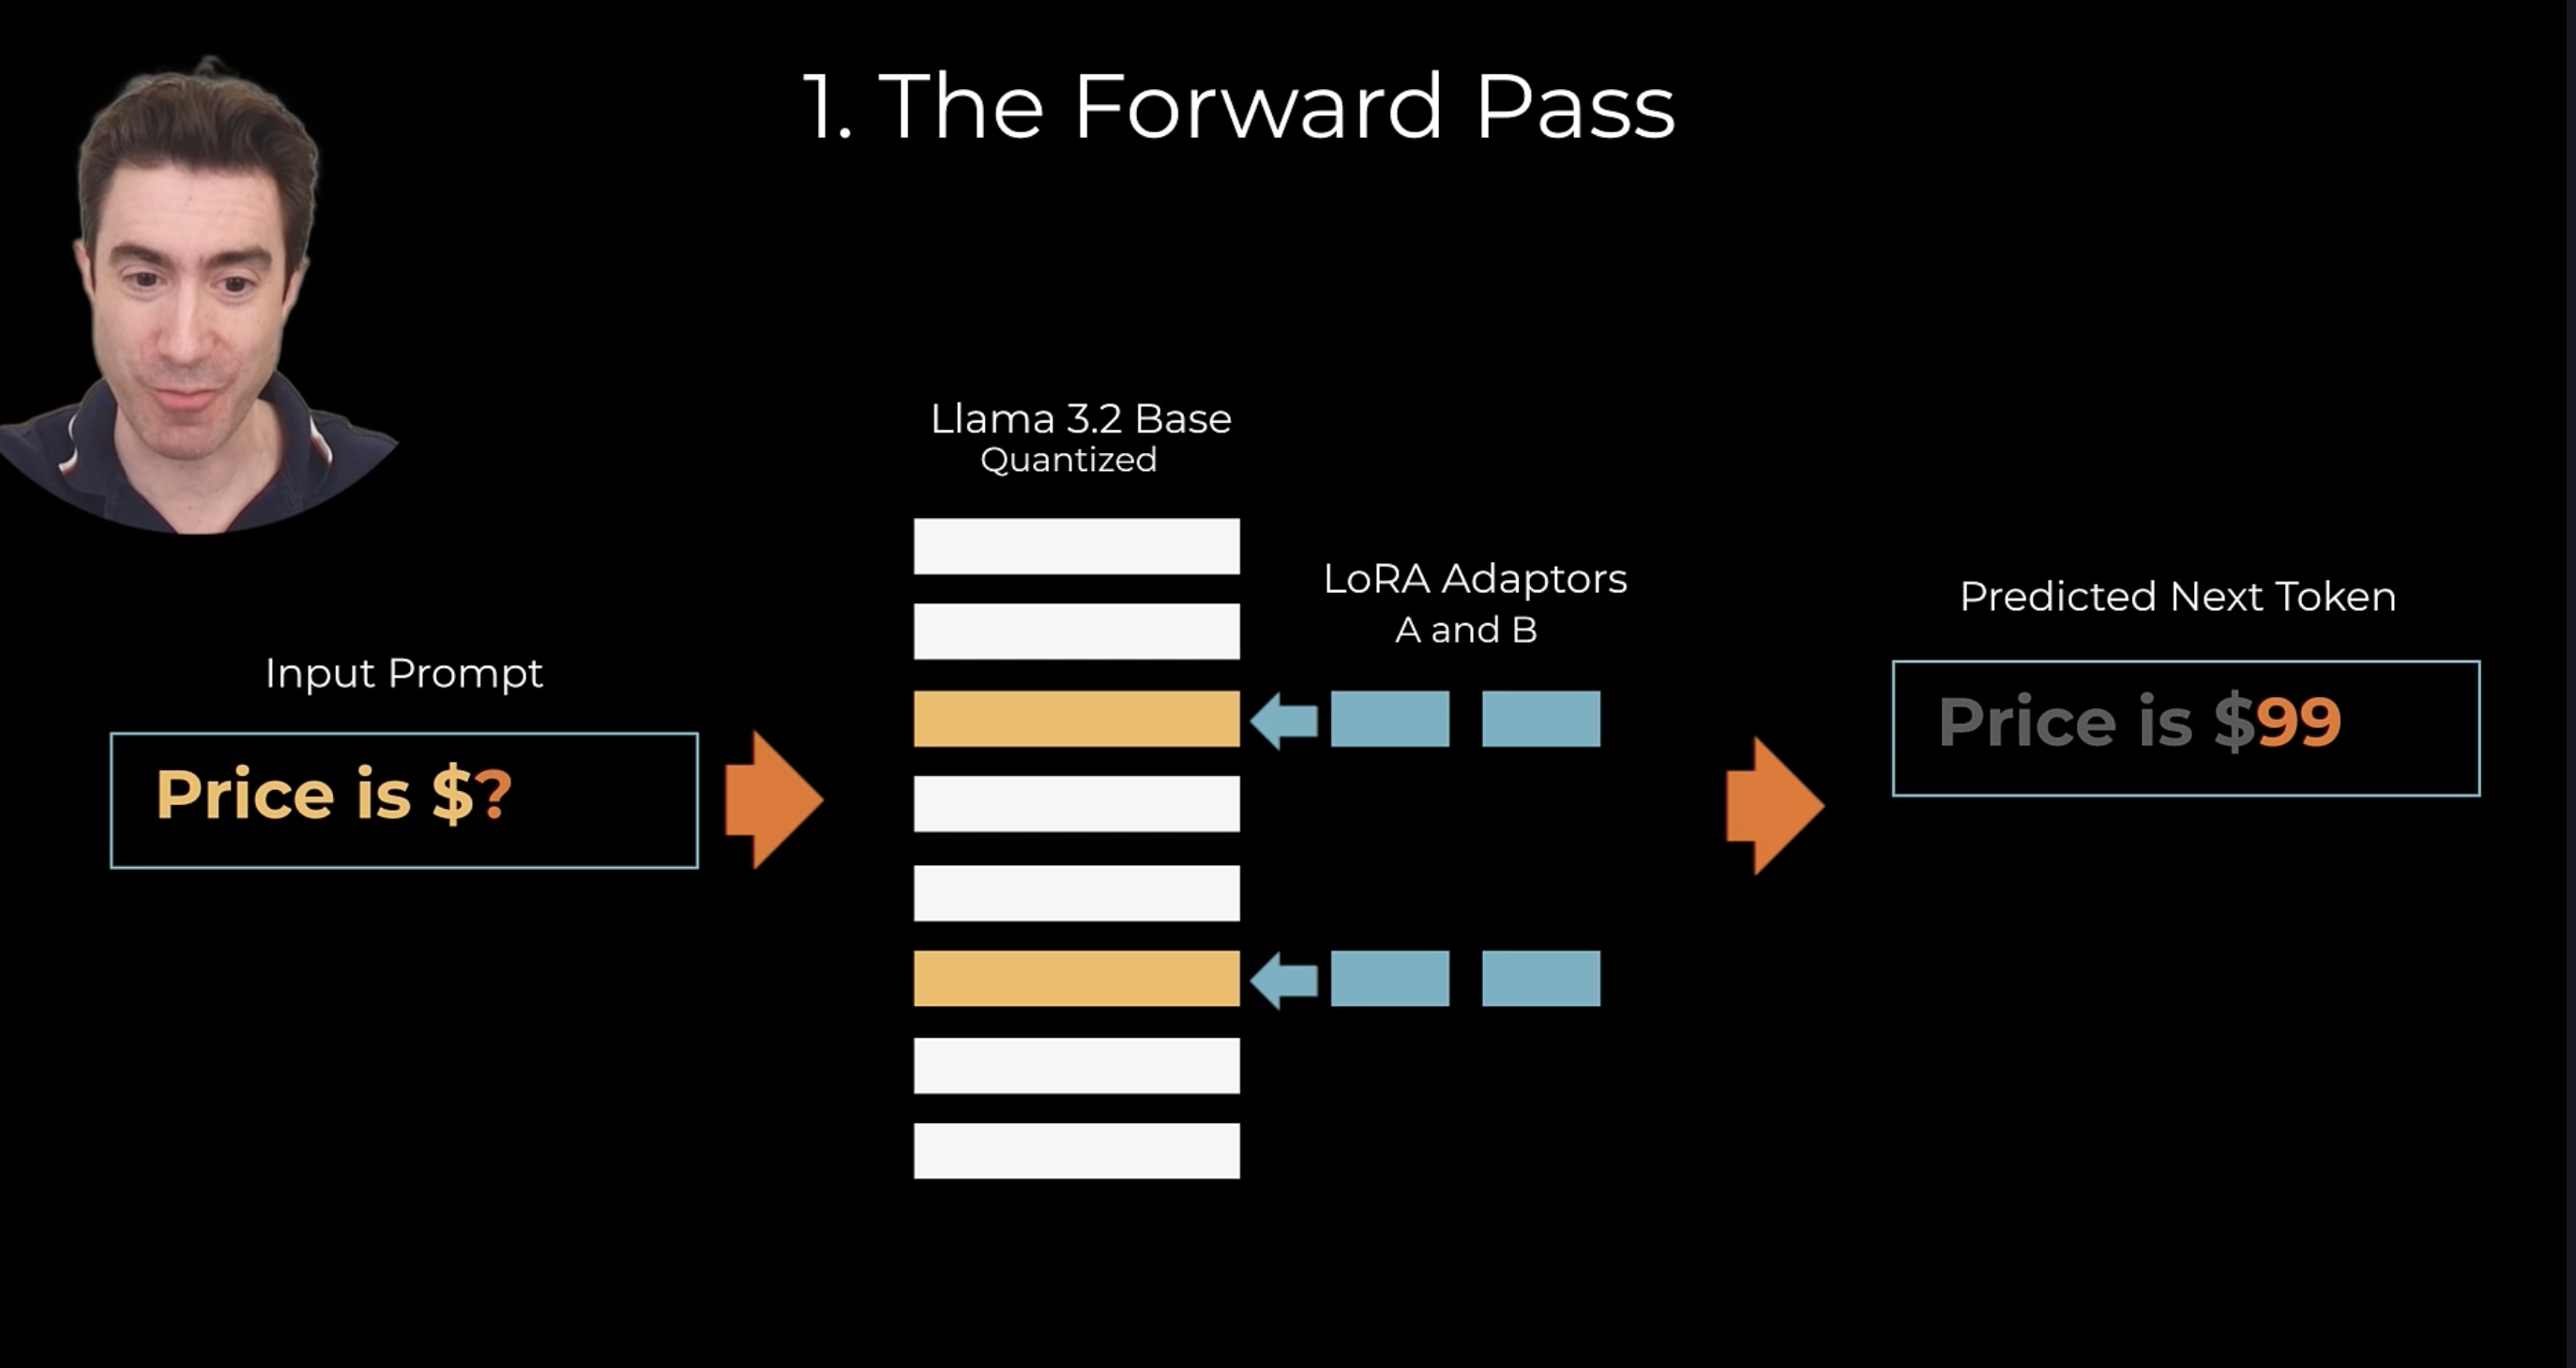

2. Loss Calculation
    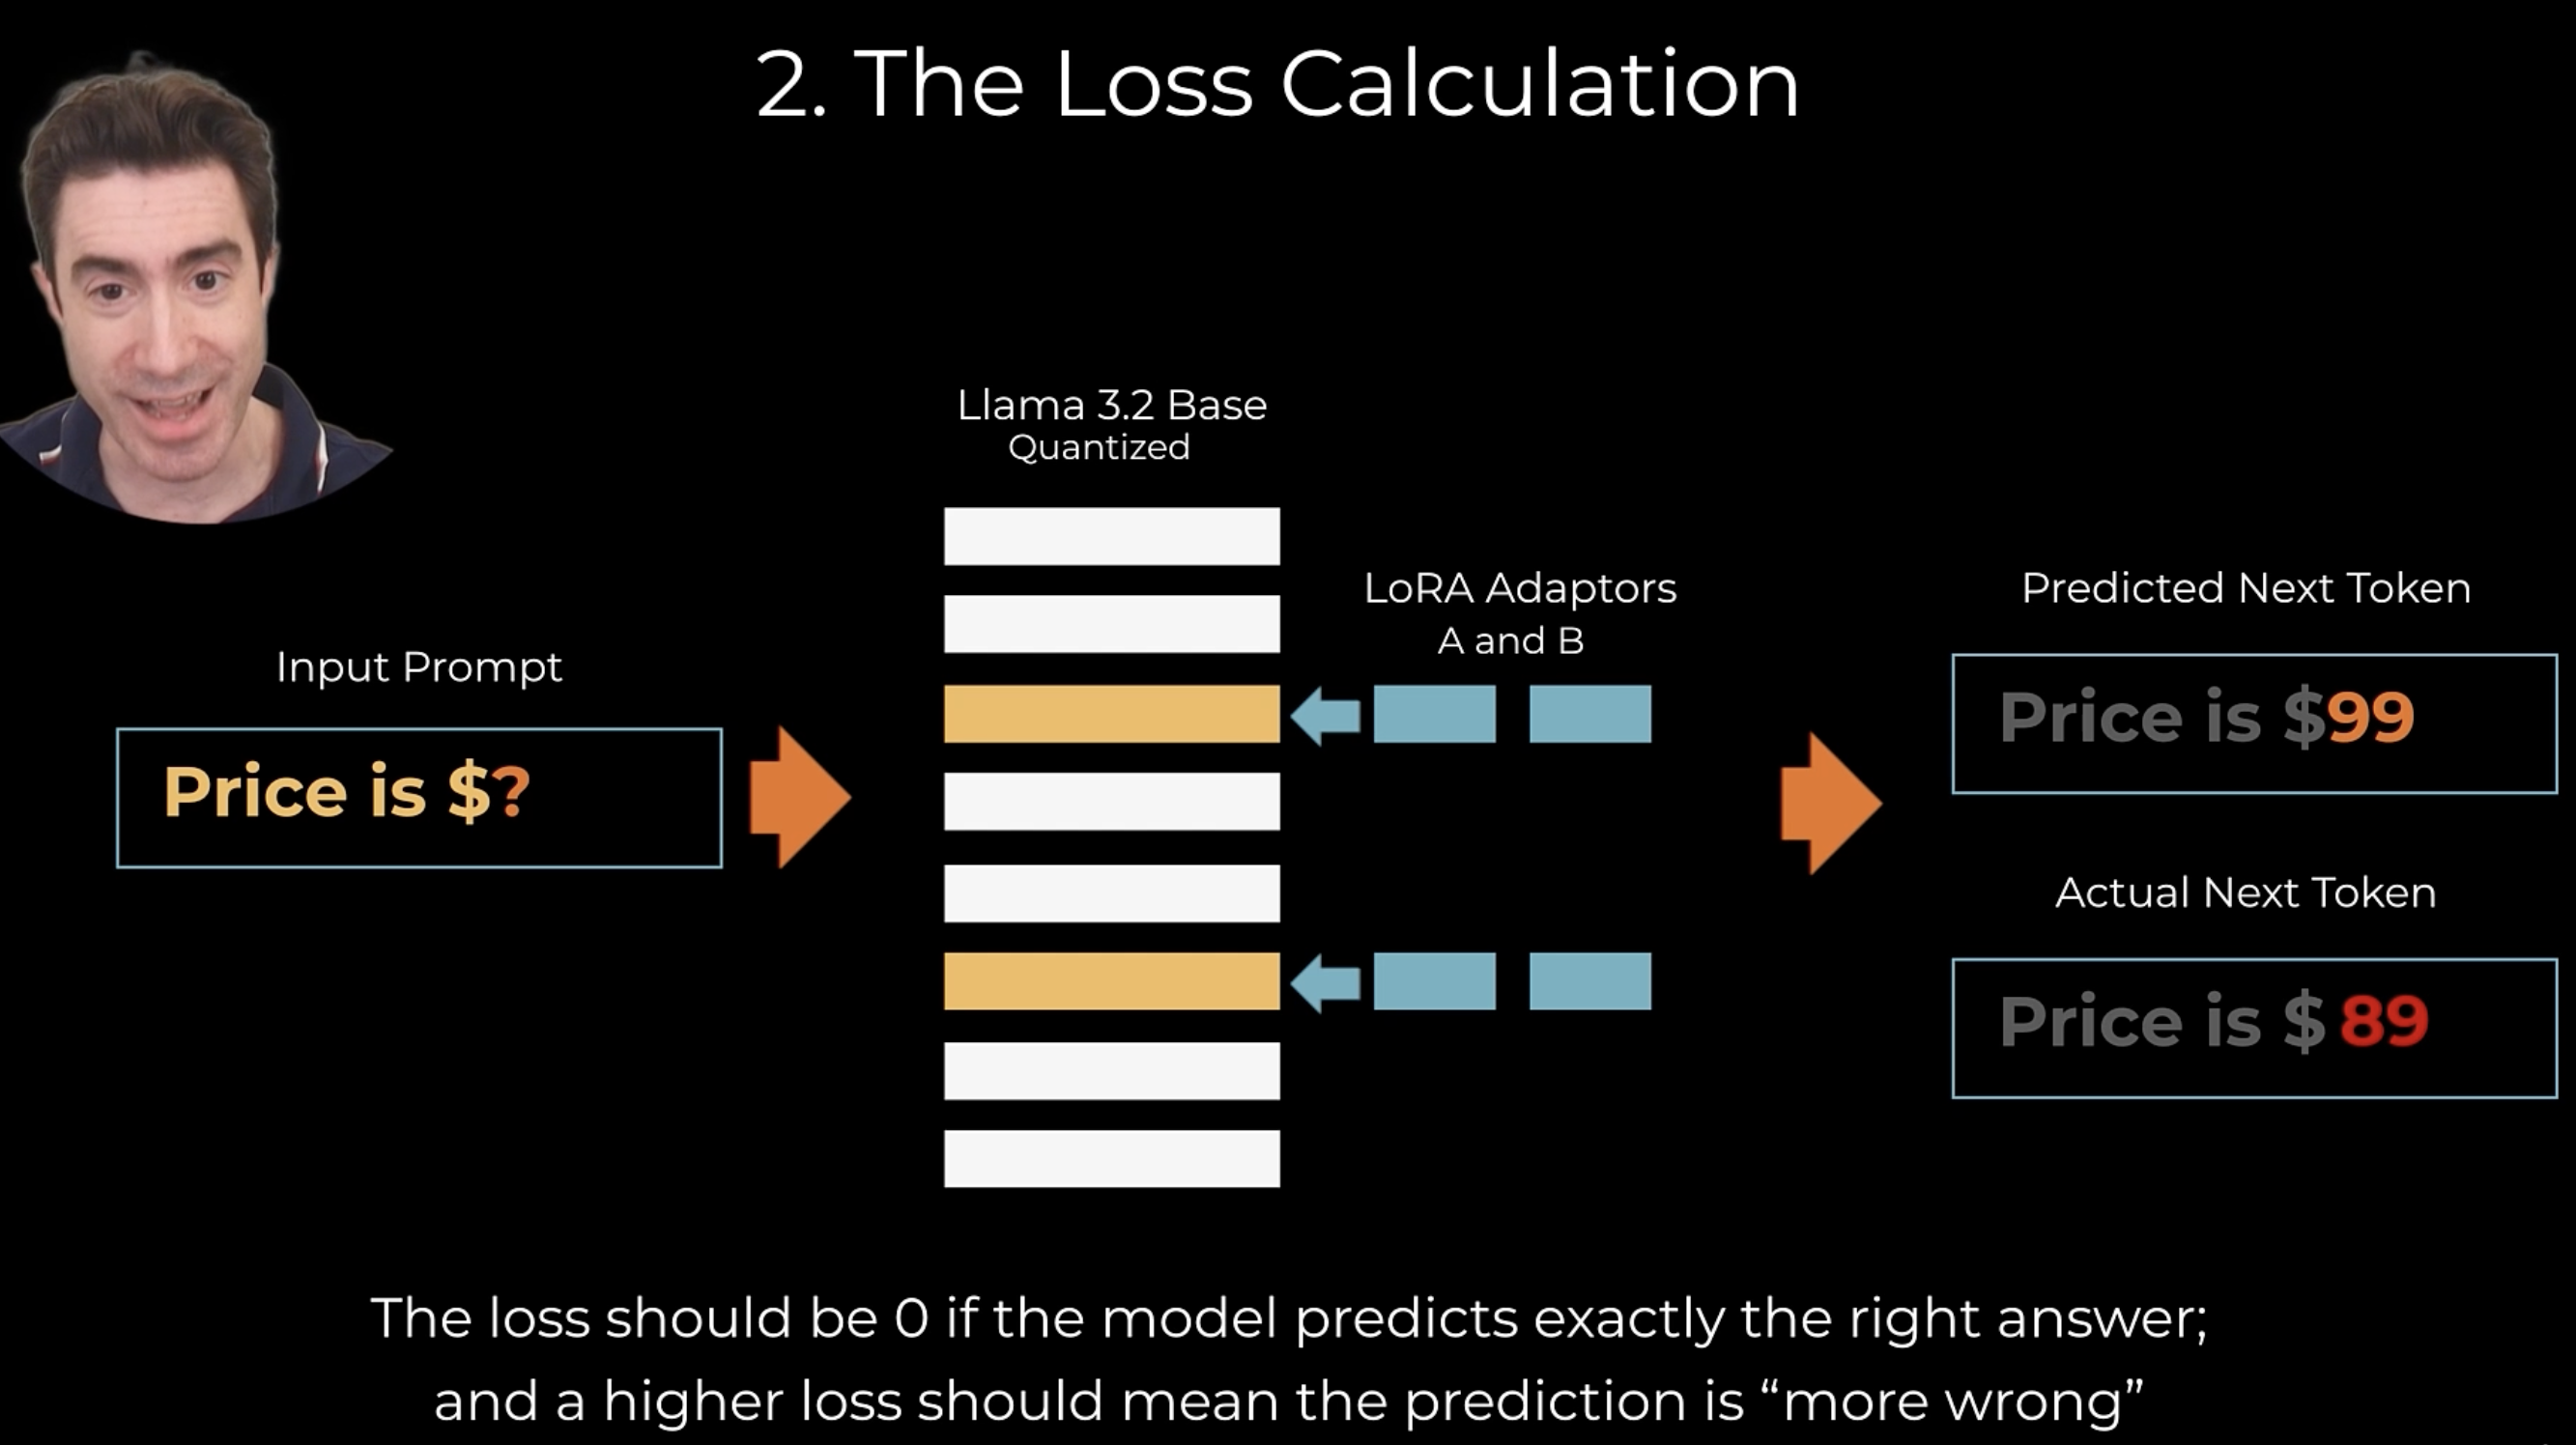

3. Backward Pass
    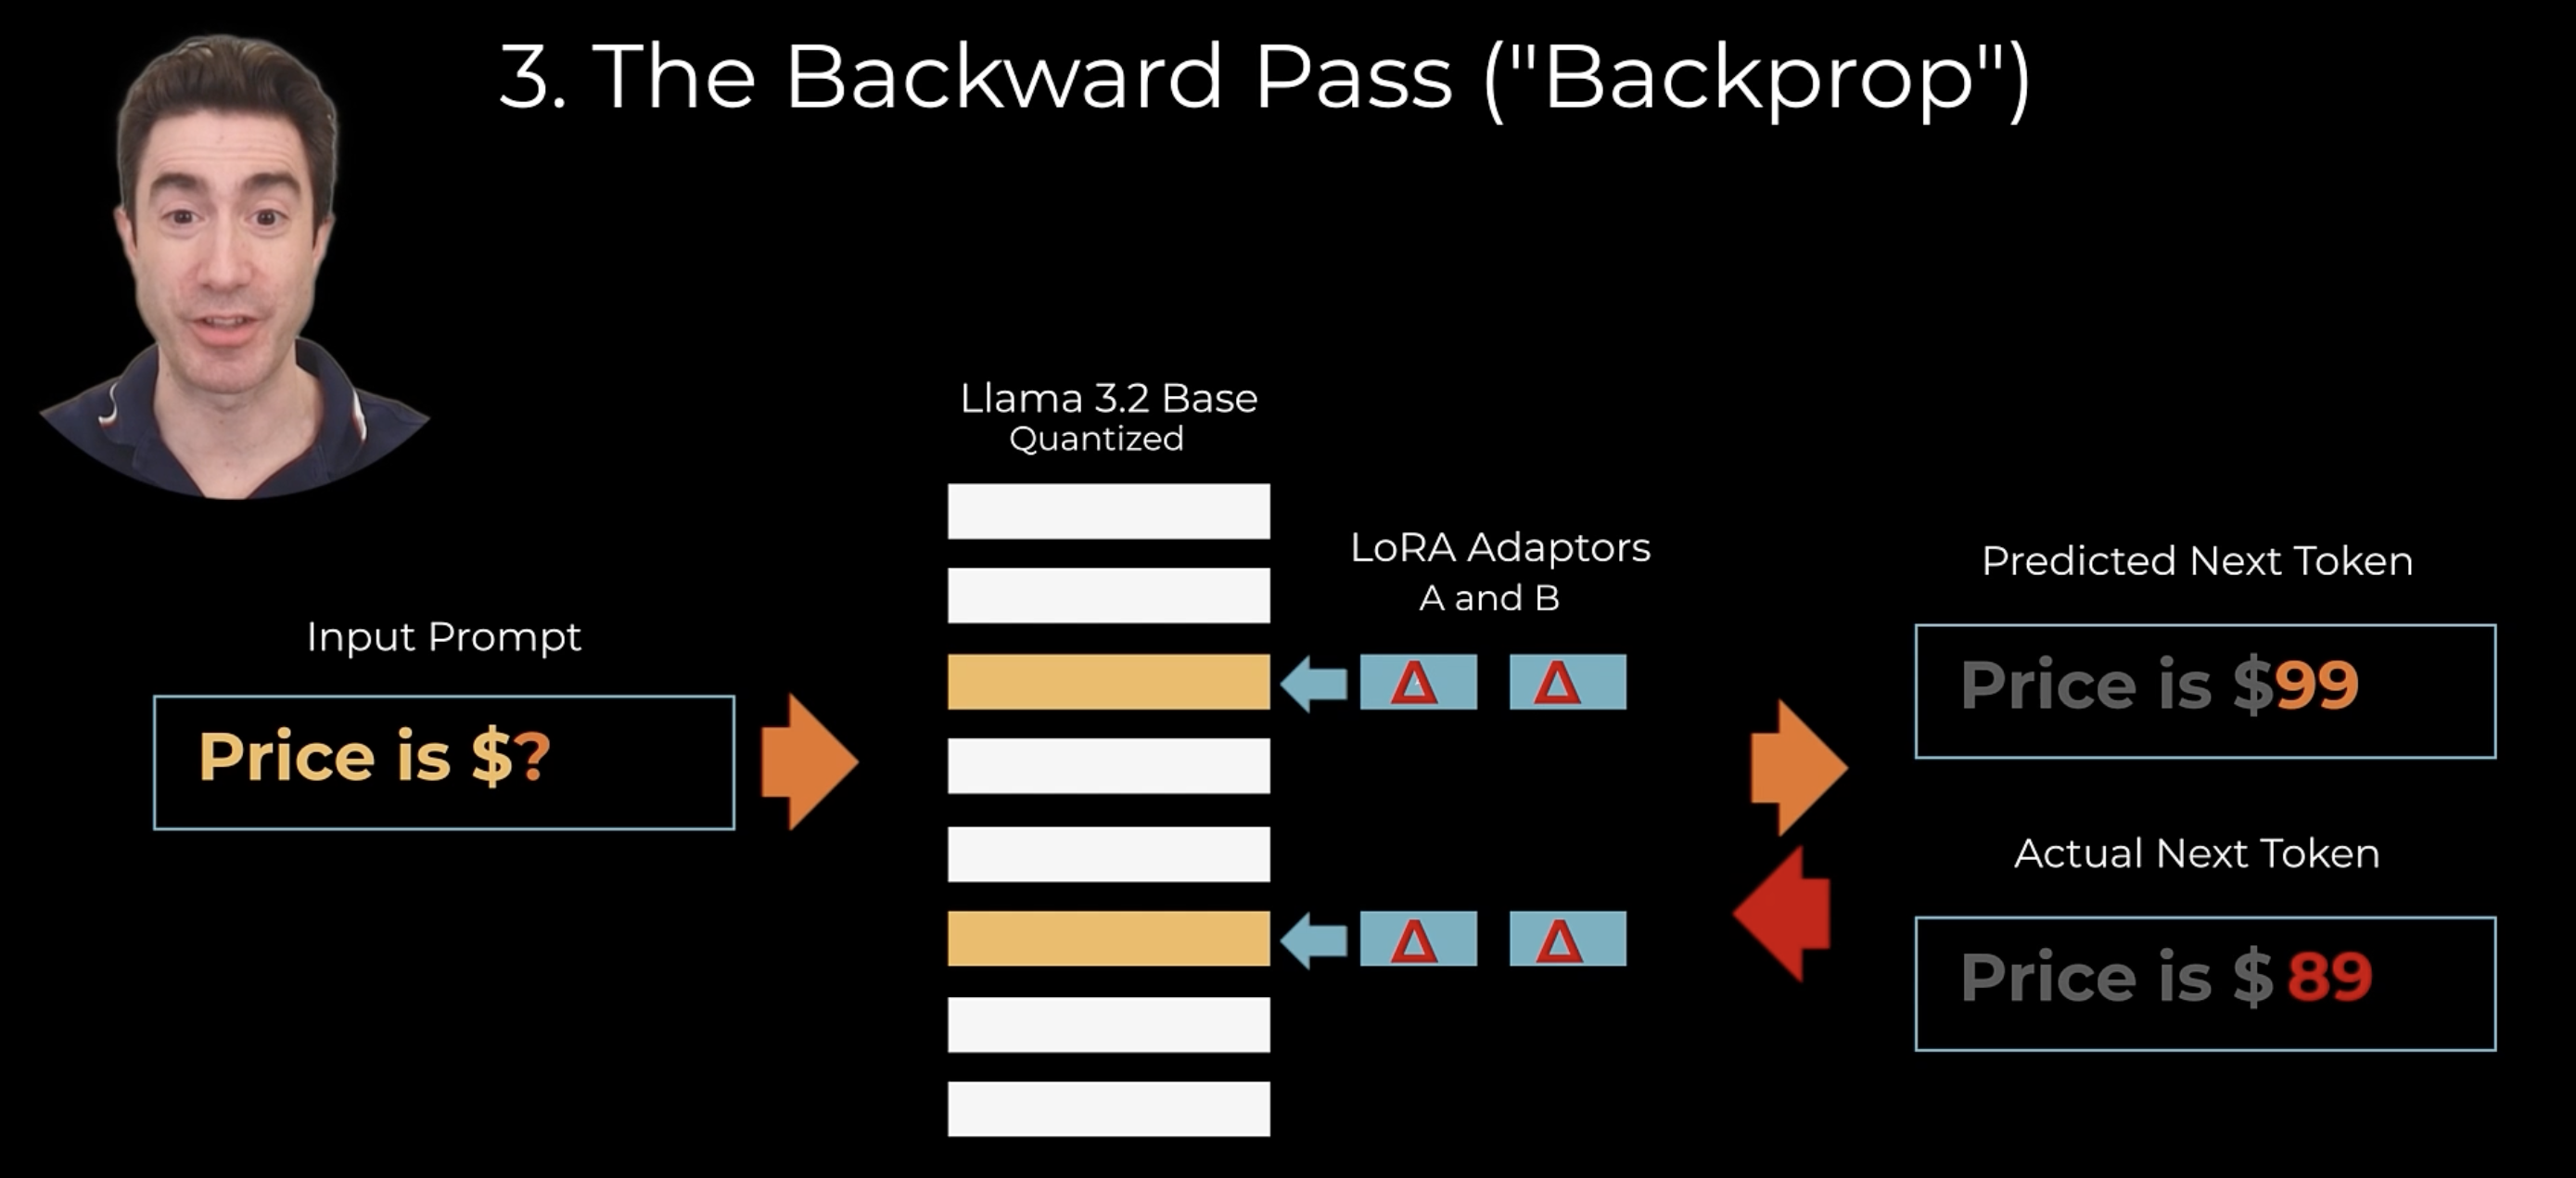

4. Optimizer
    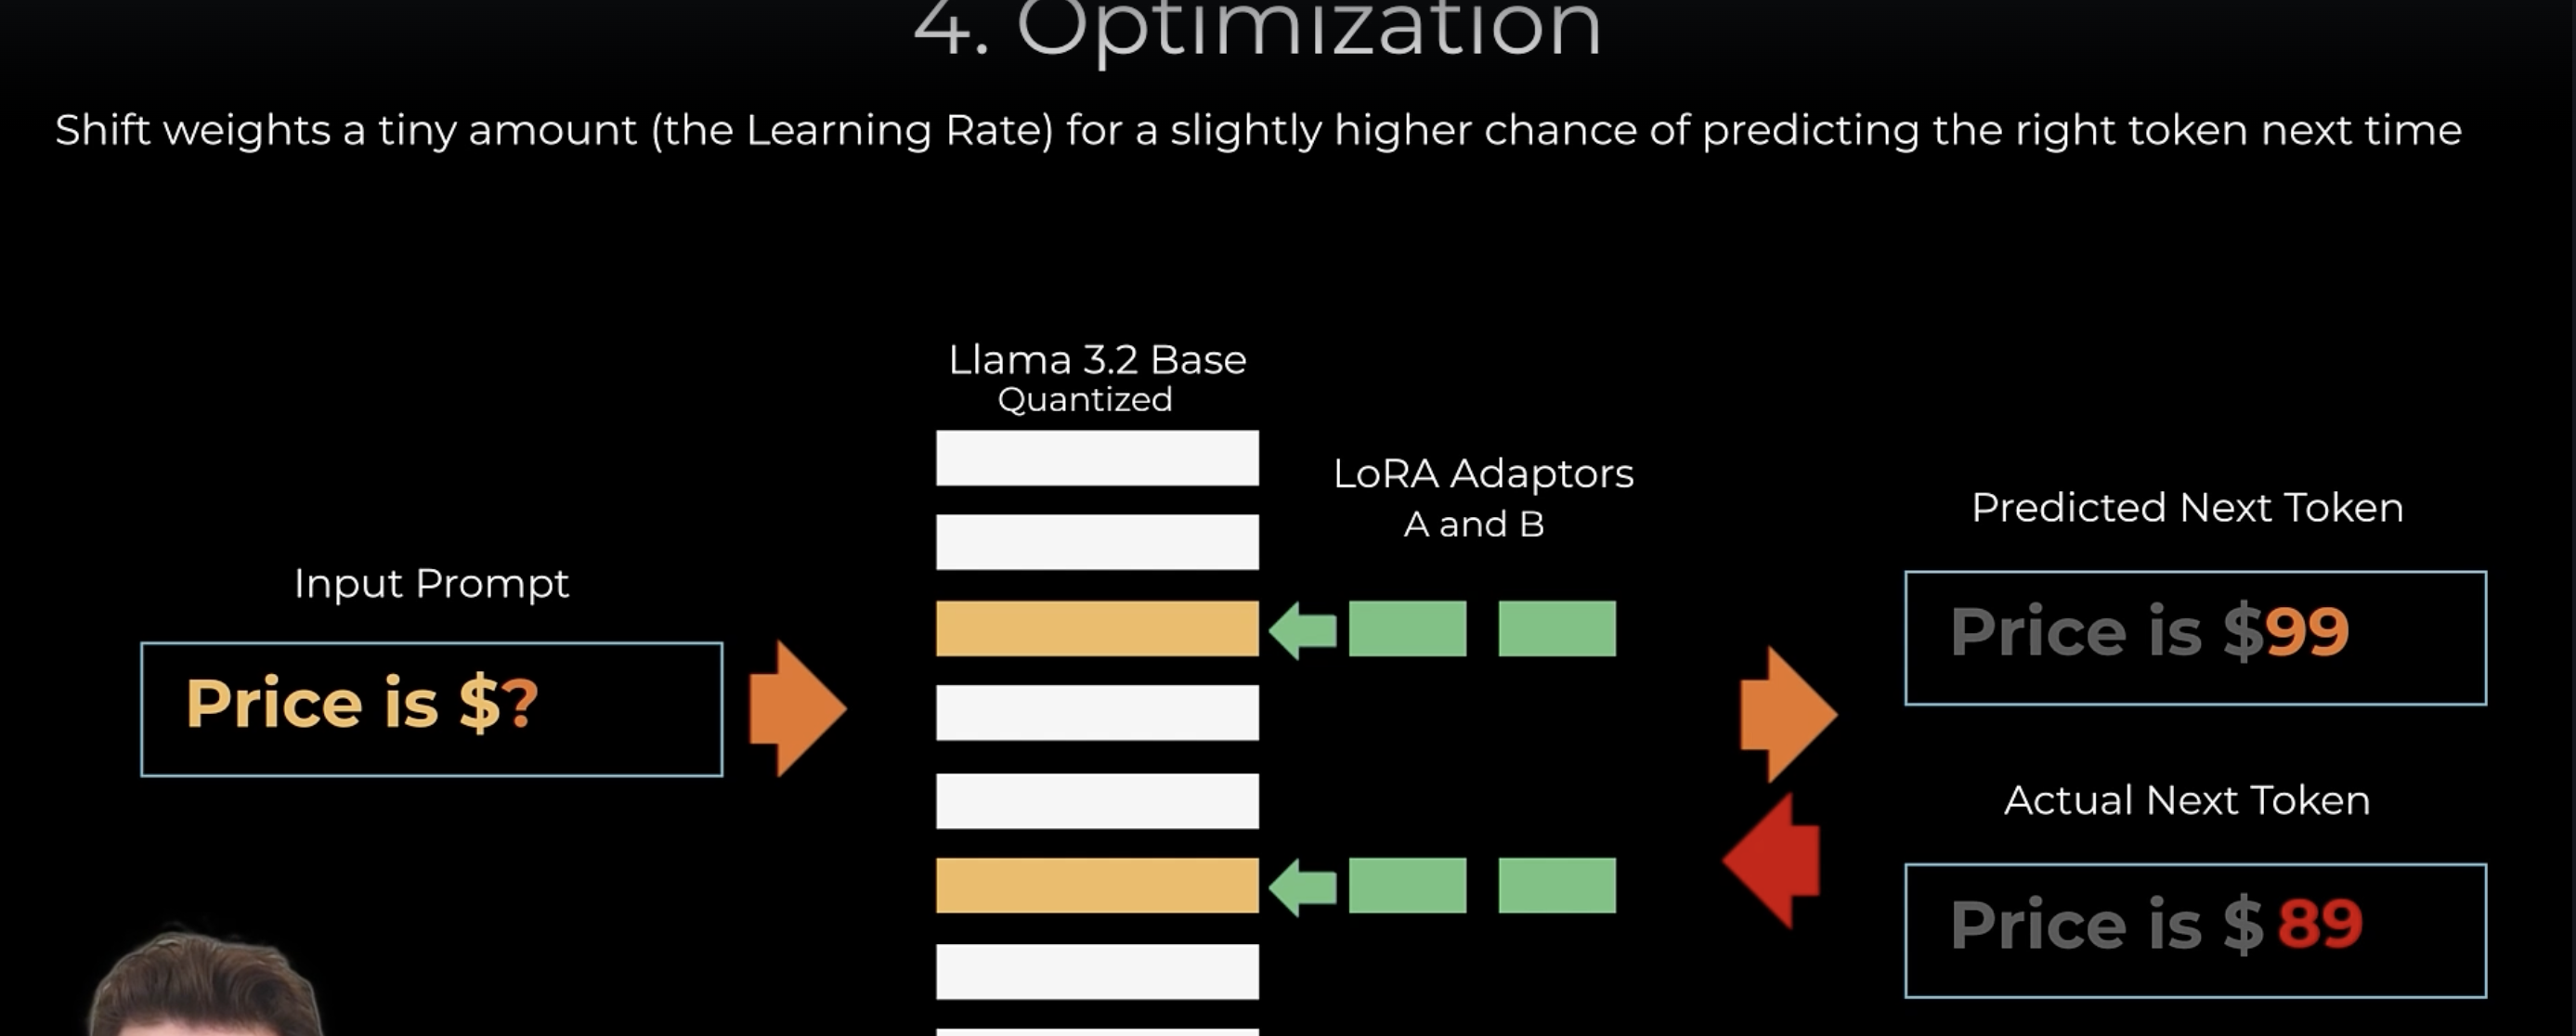

In [ ]:
# Key Terms:
1. Hyper-parameters: You can specify additional settings that are not updated during training known as hyper-parameters.
2. Epoch: No. of iterations for learning.
3. Learning Rate: Rate of change of parameters, so it perform better next time.
4. Quantization (Not a Training Technique):
    - Reduces the precision per parameter, but does nto reduce the number of parameters
    - Example:    
        - Llama 3.2-3B with Quantized to 8 bit = 3.6 GB. Althought the original model size is 13 GB
        - Instead of Storing each weight as 32 bit float, we store as 8-bit float => 8/8 => 1 byte
        - 3B * 1 byte => 3 GB + 600 MB of metadata, => 3.6



# 3. Training Techniques

In [ ]:

    
2. LoRA (Low Rank Adaptation)
    - Fine-tuning a large LLM with Billion of parameters is expensive, as it performs Full backprop through entire model.
    - So, LoRA (Low-Rank Adaptation) lets you fine-tune without changing most parameters.

    - Idea: Freeze the original model weights and learn only a small low-rank update matrix, So Instead of learning a millions of parameters, learn just a few thousands
    - Steps:
        Step 1: First, we first select a few layers, called Target Modules.
        Step 2: we create a seperate matrix/ parameters which are of a few dimensions, called Low Rank Adaptor.
        Step 3: We train the Low Rank Adaptor parameters.
        Step 4: We just add the Low Rank Adapter matrix to the selected Target Modules.
    - But there is a problem with matrix dimensions.
        - There are two matrix for each Target Module (LoRA_a, LoRA_b) which are much smaller in dimension. 
        - These are first multiplied, then it result in bigger dimension matrix, then these are scaled up by Alpah and then get added to the target module of selected layers.

    - Maths
        - In Transformers, learnable power is inside linear layers:
            -   Q, K, V projections
                Output projection
                FFN layers
        - W_new = W_frozen + ΔW
            - ΔW = A × B
              A ∈ R(d × r)
              B ∈ R(r × k)
        - Original Layer
            - y = W x
            - 4096 × 4096 = 16,777,216 params
        - LoRA Layer
            - y = W x + (A B) x
                * W is a matrix with d rows, k columns, x is input vector, y is output vector, W is trainable weights, r is much smaller number of LoRA
            -   A: 4096 × 8  = 32,768 (LoRA with rank matrix as 8)
                B: 8 × 4096  = 32,768
                ---------------------
                Total ≈ 65,536 params

# If we don't use the LoRA
    - We have to run forwards, backword pass, loss calculation, and then update on full model.


In [ ]:
# Linear Layers Calculation for LoRA with Llama 3.2B-3B

# LoRA is applied on Selective Layers
- Llama 3.2-3B, has 26-32 blocks (depends on variant) => ~30 blocks
- Each layer has around ~6 linear layer => Total linear layers => 30 * 6 => 180 layers

# Which layers of LLM usually apply LoRA
- LoRA is NOT applied to every linear layer.
- Setup 1 (very common), LoRA is applied to following 2 layers only
    - ✔ Wq (Query)
    - ✔ Wv (Value)

    - In this Setup, 30 blocks * 2 => 60 linear layers

- Setup 2, LoRA is applied to following 4 layers only
    - ✔ Wq (Query)
    - ✔ Wv (Value)
    - ✔ Wo
    - ✔ FFN projections    

    - In this Setup, 30 blocks * 4 => 120 linear layers

Transformer Block #1
 ├─ Wq  ← LoRA here
 ├─ Wk
 ├─ Wv  ← LoRA here
 ├─ Wo
 ├─ FFN W1
 ├─ FFN W2

Transformer Block #2
 ├─ Wq  ← LoRA here
 ├─ Wk
 ├─ Wv  ← LoRA here
 ...


# Why LoRA is applied selectively
- Attention Q,V control behavior most
- FFN stores general knowledge
- Fewer LoRA layers = smaller adapter
- Pros: Low memeory, Training stable, Performance high
    
    

In [ ]:
# Linear Layers additional Weight Calculation for LoRA with Llama 3.2B-3B

# LoRA formula
    ΔW = A × B
    A ∈ R(d × r)
    B ∈ R(r × k)

    r = 32 (very small)
    d = k = 4096

- In a 3B transformer (example)
    - In 30 transformer blocks * 2 linear layers (where LoRA ~100–120 linear layers adapted on which LoRA/ QLoRA will be applicable.
    - Typical hidden size ≈ 4096

- Per Layer LoRA parameters
    A: 4096 × 32 = 131,072
    B: 32 × 4096 = 131,072
    Total ≈ 262K params per layer

- For 120 linear layers, where LoRA will be applicable
    - 262K params per layer × 120 layers ≈ 31 million params

# Storage for LoRA Weights
    - LoRA usually store weigts in FP16, FP16 => 16 bits/ 8 => 2 bytes per parameter
    - 31M parameters * 2 bytes => 62 MB + some metadata => 73 MB

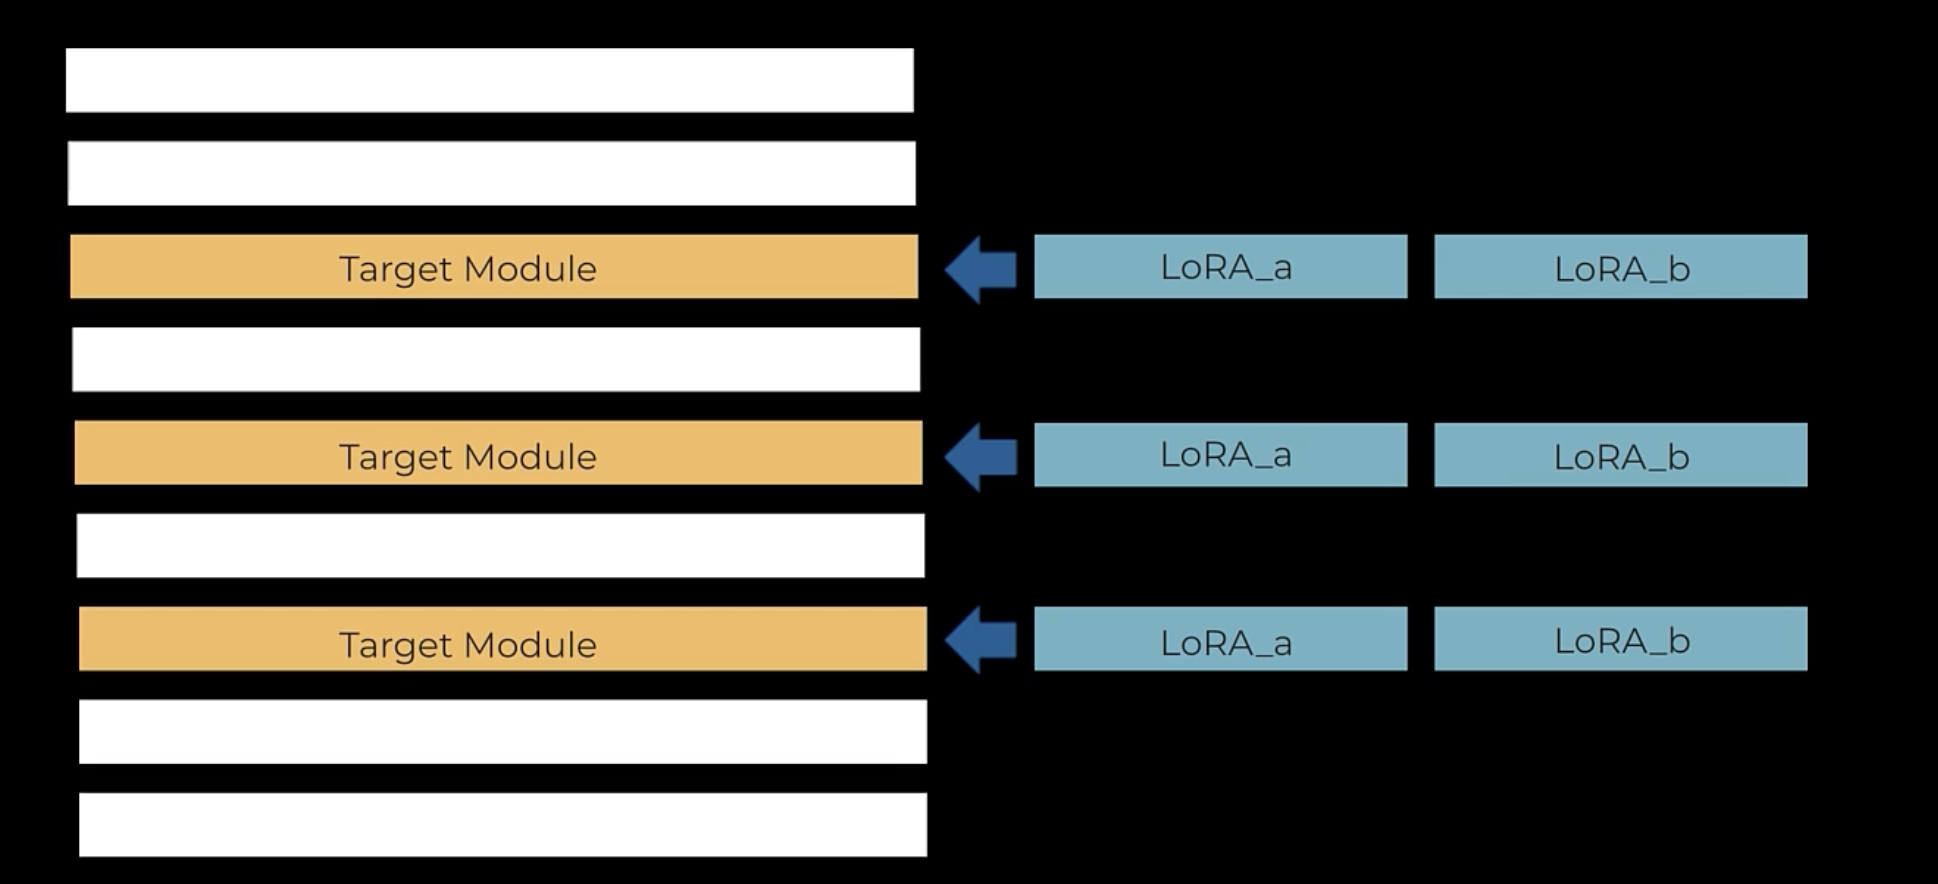

In [ ]:
3. QLoRA (Quantization Low Rank Adaptation)
    - QLoRA = Quantization + LoRA
    - Intuition: Keep the number of weights same, but reduce their precision.
    - Model performance is worse, but the impact is surprisingly small.
    - Reduce to 8 bits, or even to 4 bits. 
        - These 4 bits are interpreted as float, not int.
        - Here, quantization is done on the base model, converting to lower bits.

In [ ]:
# Quantization 
Quantization is a model-compression technique where we represent the numbers inside an LLM (weights, activations, sometimes gradients) using fewer bits than the default FP32 / FP16, while trying to keep accuracy almost the same.
Quantization is an approximation, The model is not exactly the same, just close enough.

Intution: Keep the number of weights same but reduce their precision, It is similar to light switch, by reducing precision to INT4, we are reducing the number of possible values.
          - Its like a fan/light switch has less number of possible values, (1 to 100%, the step count is reduced from like 5 to 10).      
          - Like 4BIT has 16 combinations, and 8BIT has 256 combinations.
          - This reduces the model accuracy, but not much.
          - Usually, we Reduce to 8 bits, or even to 4 bits
            Technical note 1: 4 bits are interpreted as float, not int
              
It helps in reducing the model size and in matrix multiplication computation.    
    FP16 → 16 bits/param
    INT8 → 8 bits/param  (~2× smaller)
    INT4 → 4 bits/param  (~4× smaller)

# Why Quantization is required
    - Even a small model 3B variants is very big.
    - Size: 3B * 32 bits => 13GB
    

# Reduction in Size for Llama Weights in MB
1. Llama 3.2-3B = 13 GB
    - 1 parameter = 32 bit float (default) = 32/8 = 4 bytes
    - 13B * 4 bytes => 12 GB + 1 GB Meta Data => 13 GB

2. Llama 3.2-3B with Quantized to 8 bit = 3.6 GB
    - Instead of Storing each weight as 32 bit float, we store as 8-bit float => 8/8 => 1 byte
    - 3B * 1 byte => 3 GB + 600 MB of metadata

3. Llama 3.2-3B with Quantized to 4 bit = 2.2 GB
    - Still all 3B weights are present, just very compressed.
    - 3B * 0.5 byte => 1.5 GB + 700 MB of metadata => 2.2 GB

4. Llama 3.2-3B with QLoRA (Quantization + LoRA) with r=32 = 73 MB
    - QLoRA = Quantization + LoRA
    - Part 1: Quantization
        - The entire 3B model is Quantized to 4-bit and all weights are frozen (not trainable) => 2.2 GB
        - But this is NOT what you save or upload
    - Part 2: LoRA
        - With QLoRA, you only save the Low-Rank Adapter weights (LoRA) => 73 MB


# Size Comparison
1. Llama 3.2-3B Base model
    - 3,000,000,000 parameters
    - Size: 13 GB GB

2. Llama 3.2-3B Base model (frozen, and Quantized with 8 bit)
    - 3,000,000,000 parameters
    - Size: 3.6 GB

3. LoRA adapter (saved explicitly):
    - 31,000,000 parameters (trainable)
    - 73 MB


# In Quantization, What exactly gets quantized
A. Weights
    - W ∈ FP16  →  Wq ∈ INT8 / INT4
B. Activations
    - x ∈ FP16 → xq ∈ INT8
C. Both (maximum compression): Used in highly optimized kernels.


# Core Idea and Maths
- Original
    - y = W . X
- Quantized
    - W ≈ s × Wq
    - x ≈ t × xq
    - y ≈ (s × t) × (Wq · xq)

    - Where, 
        Wq, xq = low-precision integers
        s, t   = scale factors
        Scales keep values numerically meaningful.

    # Training Part
        - During Training, original W weights are still maintained, as with INT4 training is not reliable.

    # Inference Part
        - Original W (FP16 / FP32) is REMOVED
        - Only Wq (INT8 / INT4) + scale s are stored in memeory for Inference.

# Process of Quantization
x (FP16)
 → quantize → xq (INT)
 → matmul   → Wq · xq
 → dequant  → output

# Loss in Quantization
    - Quantization error = |W − s × Wq|
    - Good quantization minimizes this.


In [ ]:
# Quantization with QLoRA
- Quantization is only applied to the base model, converting it to (8 or 4 bits). The LoRA adapters matrices are still in origin 32/16 bits.
    
- Base model weights are quantized (Wq)
    - W_base = quantized (No original W)
    - W_base quantized are to INT4 / INT8
    - NOT trainable, Used only for forward pass

- LoRA adapters are still in original FP32/FP16
    - LoRA adapters are kept in original because they must be trainable and numerically stable, while the quantized base weights are frozen.
    - Why adapter can not be in INT8/ INT4 ?
        - Because Training requires Backpropagation, Gradient accumulation, Small weight updates and Low-bit integers break all three.


# 4. Fine Tuneing with Closed Source LLM models

### 1. Fine-Tuning with Open AI

In [ ]:
# Fine-Tuning
# Page: 

Traning generates a small model with the customized weights, which is private only for the user. Only a small number of parameters are updated.

- LORA: To change a small number of parameters, that affects the bigger model. 

# Type of Training on OpenAI
1. Supervised fine-tuning
    - https://platform.openai.com/docs/guides/supervised-fine-tuning
    - It lets you train an OpenAI model with examples for your specific use case. The result is a customized model that more reliably produces your desired style and content.
    - Best for:
        - Classification
        - Nuanced translation
        - Generating content in a specific format
        - Correcting instruction-following failures

2. Direct preference optimization
    - Provide both a correct and incorrect example response for a prompt. Indicate the correct response to help the model perform better.
    - Best for:
        - Summarizing text, focusing on the right things
        - Generating chat messages with the right tone and style

            
3. Reinforcement fine-tuning
    - When we don't have correct/ expected results, instead we may add a judge to grade the results, and reinfornce the model's chain of though for higher scored responses.
            
            
# Fine turning is very similar to batch mode.

# Steps
1. Create Training dataset in Jsonl format (each line is a json format) and upload to Open AI
2. Run training - training loss and validation loss should decrease
3. Evaluate results, tweak and repeat

In [ ]:
# Data Points in fine turning
- Open AI recomends fine-tuning with a small population of 50-100 examples only.
  Because we are working on a heavyly trained model, as it has already been trained.

Key Objectives of Fine-Tuning for Frontier models
    1. Setting style or tone in a way that can't be achieved with prompting
    2. Improving the reliability of producing a type of output
    3. Correcting failures to follow complex prompts
    4. Handling edge cases
    5. Performing a new skill or task that's hard to articulate in a prompt    

# 5. Fine Tuneing with Open Source LLM models

# 6. Hyper Parameters

In [ ]:
# Hyper parameters for QqLoRA Fine-Tuning
1. Rank: How many dimensions in the low-rank matrices.
    - Rule: Start with 8, then double to 16, 32, untill diminishing returns

2. Alpha: A scaling factor that multiplies the lower rank matrices, before we add it to the base model.
    - Rule: Twice the value of r

3. Target Modules: Which layers of the neural network will be targeted for LoRA matrix/ also called adapted.
    - Rule: Start by trageting the attention heads. Later, if required MLP layers can be included as well.

4. Quantization
    - 8Bit or 4 Bit

5. Dropout
    - Dropout probability, usually 10%.
    - Randomly 10% of the neurons will get zeroed out/ wiped out, different neurons each time.
    - Why: Technique to generallise well, model does not get over-fit. Else the model will not be generalizing/ or learning general behaviour.
    - Mainly to avoid over-fitting.

6. Epochs
    - The learning rate is very small, with every iteration the model improves.
    - Data is usually pass to model in batches, one batch is randomly selected data from the training data. So, Each batch is not identical with each iteration.

7. Batch Size
    - How many of these training data you put in one batch.
    - Rule: Pick the bigest batch size (16, 32, 64, ...). Fit as much as possible data in one batch, the system GPU can fit in.

8. Learning Rate
    - How big a step you take in learning each time. 
    - How much loss changes in each direction.
    - Rule: Start with 0.001 

9. Gradient Accumulation: To speed up training
    - Usually, In every iteration we do, the forward pass, loss calculation, backward pass, Update weight.
    - But Gradient Accumulation says, do not update the weight in every iteration and just accumulate update, and later just update the weight once at all, after certain iterations.

10. Optimizer
    - STD (Stochastic gradient descent)
    - Adam

# 7. Saving Training Logs

In [ ]:
1. WandB
    - https://wandb.ai/srvaggarwal96-abes/amazon-product-price?nw=nwusersrvaggarwal96

a. Graph 1: train/loss
    - Hyperparameter, LOG_STEPS = 5
    - At every 5 step while training, the metrics get logged to WandB
    - With the 2 and 3 Epoch, there is a significant drop in graph, which is like over-fitting, as model has already seen that data. So, In 3rd Epoch that training data seems familier to model. But, that does not mean, it will perform good on unseen data/ validation loss.
        
b. Graph 2: eval/loss
    - It is the most important graph.
    - Loss on the unseen validation data.
    - In the beigning of the chart, there is spike, that is because of high learning rate in the beigning, something like it jumped local minima, and moved on the other side.

c. Graph 3: Learning Rate
    - Initially Learning Rate goes from 0 to 0.0001, that is the warm-up period.
    - Then it stays constant for sometime.
    - Then it starts decreasing because of the learning rate scheduler.
    - If there are 10 EPOCHS, then learning does not reset after each epoch, it gradually follows cosine graph over all the input Epochs.

# Overfitting
    - In train/loss graph, the loss drops significantly at the 3rd Epoch. But In the eval/loss, the loss increased significantly at the 3rd Epoch. This is a clear indication of overfitting.
    - It was productive till 2nd Epoch only. 
    - Use Hyper-parameters
        - Increase Dropout from 10% to 20% 
        

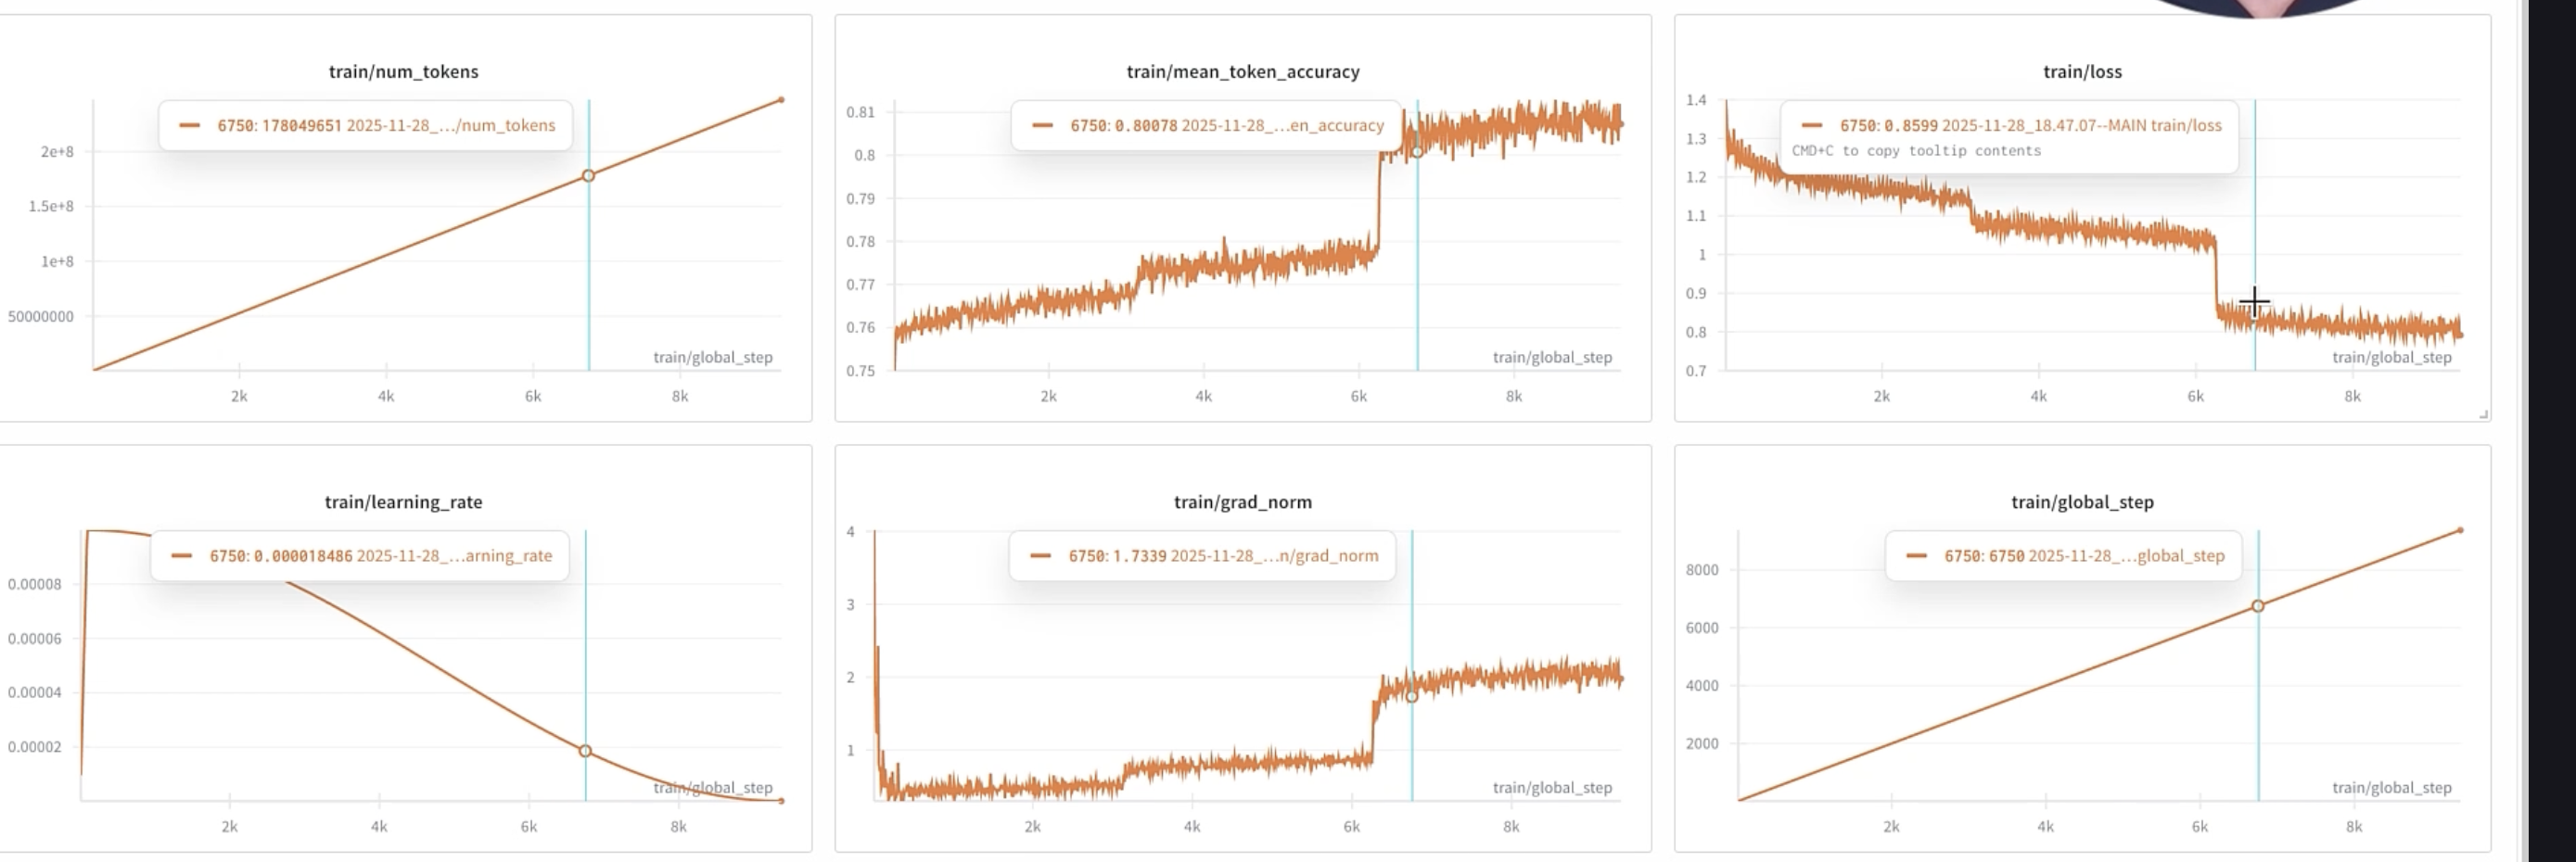
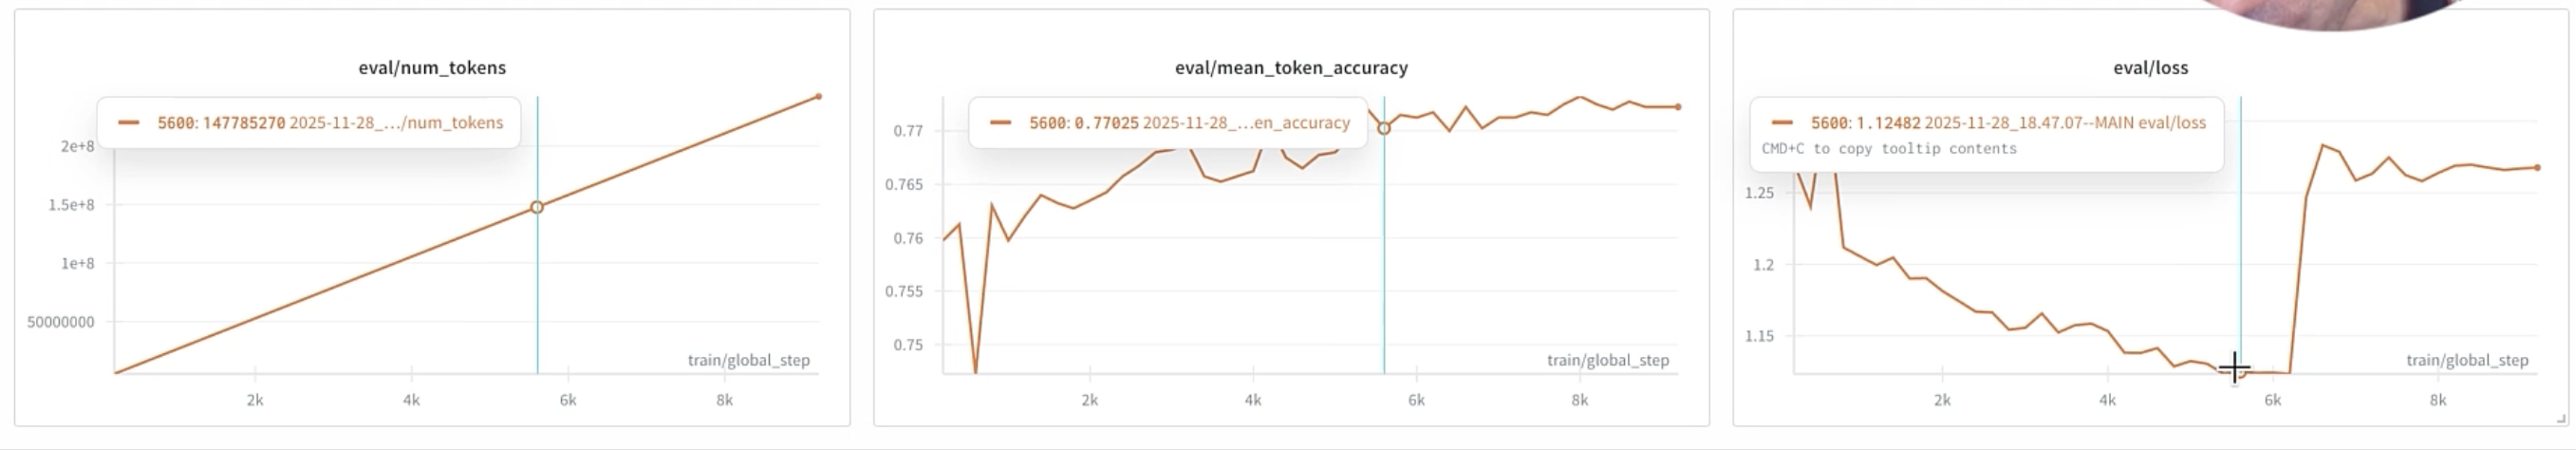

# 8. Structured Outputs from an LLM

In [ ]:
1. Open AI

response = openai.chat.completions.parse(model=MODEL, messages=messages, response_format=DealSelection, reasoning_effort="minimal")
results = response.choices[0].message.parsed
results